# Get Driver Telemetry

In [ ]:
!pip install fastf1
import fastf1
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs('cache', exist_ok=True)
fastf1.Cache.enable_cache('cache')

def get_driver_telemetry(year, race, driver, session_type='R'):
    """
    returns telemetry joined with lap metadata for one driver in one session
    parameters:
        year (int): season year
        race (str): race name, e.g. 'Bahrain'
        driver (str): 3-letter code, e.g. 'VER'
        session_type (str): 'R', 'Q', 'FP1', etc.
    """
    #load session
    session = fastf1.get_session(year, race, session_type)
    session.load()

    #driver laps
    laps = session.laps.pick_driver(driver)
    #convert lap time to seconds
    laps['LapTime'] = laps['LapTime'].dt.total_seconds()

    #get stint lap number (sometimes different from tire age due to changing into used tires)
    laps['StintLap'] = laps.groupby('Stint').cumcount() + 1

    #ADD NOISY LAP FLAG
    valid_laps = laps[laps['StintLap'] > 1]['LapTime']
    Q1 = valid_laps.quantile(0.25)
    Q3 = valid_laps.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    laps['NoisyLapFlag'] = ((laps['LapTime'] < lower) | (laps['LapTime'] > upper)).astype(int)

    #ADD WARM UP LAP FLAG (first 2 laps of any stint)
    laps['WarmupLapFlag'] = (laps['StintLap'] <= 2).astype(int)

    #initialize telemetry table
    all_tel = []
    #build table
    for _, lap in laps.iterlaps():
        try:
            tel = lap.get_car_data().add_distance()
            #add lap metadata
            tel['LapTime'] = lap['LapTime']
            tel['Compound'] = lap['Compound']
            tel['LapNumber'] = lap['LapNumber']
            tel['Stint'] = lap['Stint']
            tel['TyreLife'] = lap['TyreLife']
            #add calculated columns
            tel['StintLap'] = lap['StintLap']
            tel['WarmupLapFlag'] = lap['WarmupLapFlag']
            tel['NoisyLapFlag'] = lap['NoisyLapFlag']
            #add session metadata
            tel['Driver'] = driver
            tel['Race'] = race
            all_tel.append(tel)
        except:
            continue
    full_tel = pd.concat(all_tel, ignore_index=True)

    return full_tel


# XGBoost Model Preprocessing / Feature Engineering

In [27]:
def get_all_data(driver, race):
  #years to train on: '19, '21, '23, '25
  years = [2019, 2021, 2023, 2025]
  tel = []
  for year in years:
    tel_year = get_driver_telemetry(year, race, driver)
    tel.append(tel_year)
  tel = pd.concat(tel, ignore_index=True)
  return tel

def preprocess(tel):
  #get year column from date
  tel['Year'] = pd.to_datetime(tel['Date']).dt.year
  #remove all data where WarmupLapFlag or NoisyLapFlag = 1
  tel = tel[(tel['WarmupLapFlag'] == 0) & (tel['NoisyLapFlag'] == 0)]
  #Brake is True/False, convert to 1/0
  tel['Brake'] = tel['Brake'].astype(int)
  #1/0 boolean functions: nGear >=7, and Throttle = 100
  tel['nGear_7or8'] = tel['nGear'].apply(lambda x: 1 if x >= 7 else 0)
  tel['Throttle_100'] = tel['Throttle'].apply(lambda x: 1 if x == 100 else 0)
  #aggregate data to get by-lap features and metadata
  aggs = {  'RPM': ['mean', 'max'],
            'Speed': ['mean', 'max', 'min', 'std'],
            'Throttle': ['mean', 'std'],
            'nGear_7or8': ['mean'],
            'Throttle_100': ['mean'],
            'Brake': ['mean'],
            'LapTime': ['first'],
            'Stint': ['first'],
            'StintLap': ['first'],
            'Compound': ['first'],
            'Driver': ['first'],
            'Race': ['first']}
  #group by Year and LapNumber, keeping them as columns (as_index=False)
  tel = tel.groupby(['Year', 'LapNumber'], as_index=False).agg(aggs)
  tel.columns = [f'{c[0]}_{c[1]}' if c[1] else c[0] for c in tel.columns]

  #rename columns
  tel = tel.rename(columns={
      'LapTime_first': 'LapTime',
      'Throttle_100_mean': 'Throttle_100_pct',
      'nGear_7or8_mean': 'nGear_7or8_pct',
      'Stint_first': 'Stint',
      'StintLap_first': 'StintLap',
      'Compound_first': 'Compound',
      'Driver_first': 'Driver',
      'Race_first': 'Race'
  })
  #add lag columns
  features_to_lag = ['LapTime', 'Speed_max', 'Throttle_100_pct', 'Brake_mean']
  for feature in features_to_lag:
    tel[f'{feature}_lag1'] = tel.groupby(['Year', 'Stint'])[feature].shift(1)
    tel[f'{feature}_lag1'] = tel[f'{feature}_lag1'].where(
        tel['LapNumber'] - tel.groupby(['Year','Stint'])['LapNumber'].shift(1) == 1
    )
    tel[f'{feature}_lag2'] = tel.groupby(['Year', 'Stint'])[feature].shift(2)
    tel[f'{feature}_lag2'] = tel[f'{feature}_lag2'].where(
        tel['LapNumber'] - tel.groupby(['Year','Stint'])['LapNumber'].shift(2) == 2
    )
    tel[f'{feature}_lag1_delta'] = tel[f'{feature}_lag1'] - tel[feature]
    tel[f'{feature}_lag2_delta'] = tel[f'{feature}_lag2'] - tel[feature]
  #next lap
  tel['LapTime_next'] = tel.groupby(['Year', 'Stint'])['LapTime'].shift(-1)
  tel['LapTime_next'] = tel['LapTime_next'].where(
      tel['LapNumber'] - tel.groupby(['Year','Stint'])['LapNumber'].shift(-1) == -1
  )
  #encode tire compound
  tel['Soft'] = tel['Compound'].str.contains('SOFT').astype(int)
  tel['Medium'] = tel['Compound'].str.contains('MEDIUM').astype(int)
  tel['Hard'] = tel['Compound'].str.contains('HARD').astype(int)
  #NO NULL TARGETS!
  tel = tel.dropna(subset=['LapTime_next'])
  tel['NextLapDelta'] = tel['LapTime_next'] - tel['LapTime']
  return tel

# Add PaceDeg Model Delta Predictions

In [3]:
#connect to drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
#import pace deg coefficients
pace_deg_coef = pd.read_csv(r'/content/drive/MyDrive/ML/pacedeg_coefficients.csv')
pace_deg_coef['Race'] = pace_deg_coef['Race'].str.replace(' Grand Prix', '')
pace_deg_coef.head()

def get_pace_deg_delta(tel):
  #left join tel with coeff table on race and compound
  tel = tel.merge(pace_deg_coef, on=['Race', 'Compound'], how='left')
  #calculate delta
  tel['DeltaPred_PaceDegModel'] = (tel['Tire_Coef'] * tel['StintLap']) + tel['Baseline_Pace']
  #drop original columns
  tel = tel.drop(columns=['Tire_Coef', 'Baseline_Pace'])
  return tel

# Model Construction

In [33]:
import xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np

features = ['RPM_mean', 'RPM_max', 'Speed_mean', 'Speed_max', 'Speed_min',
            'Speed_std', 'Throttle_mean', 'Throttle_std', 'nGear_7or8_pct',
            'Throttle_100_pct', 'Brake_mean', 'LapTime', 'LapTime_lag1',
            'LapTime_lag2', 'LapTime_lag1_delta', 'LapTime_lag2_delta',
            'Speed_max_lag1', 'Speed_max_lag2', 'Speed_max_lag1_delta',
            'Speed_max_lag2_delta', 'Throttle_100_pct_lag1', 'Throttle_100_pct_lag2',
            'Throttle_100_pct_lag1_delta', 'Throttle_100_pct_lag2_delta',
            'Brake_mean_lag1', 'Brake_mean_lag2', 'Brake_mean_lag1_delta',
            'Brake_mean_lag2_delta']

model_info = pd.DataFrame(columns=['Driver', 'Race', 'RMSE', 'MAE'])

def xgb_param_tune(tel, driver='NA', race='NA'):
  X = tel[features]
  y = tel['NextLapDelta']
  #train test split
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  #set up model
  xgb = XGBRegressor(
      objective='reg:squarederror',
      eval_metric='rmse',
      random_state=42,
      tree_method='hist'
  )
  #set up param grid
  param_grid = {
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10],
  }
  #randomized search
  cv = KFold(n_splits=4, shuffle=True, random_state=42)
  #change cv so that
  random_search = RandomizedSearchCV(
      estimator=xgb,
      param_distributions=param_grid,
      n_iter=25,
      scoring='neg_mean_squared_error',
      n_jobs=-1,
      cv=cv,
      verbose=2,
      random_state=42
  )
  random_search.fit(X_train, y_train)
  #select best model
  best_model = random_search.best_estimator_
  print("Best Params:\n", random_search.best_params_)
  #evaluate on test set
  y_pred = best_model.predict(X_test)
  mae = mean_absolute_error(y_test, y_pred)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  print("Test MAE:", mae)
  print("Test RMSE:", rmse)
  #add model data to model performance table
  model_info.loc[len(model_info)] = [driver, race, rmse, mae]
  return best_model

# Build model for all 15 driver-track combinations

In [ ]:
#ensure model info is blank!!!
model_info = pd.DataFrame(columns=['Driver', 'Race', 'RMSE', 'MAE'])

features = ['RPM_mean', 'RPM_max', 'Speed_mean', 'Speed_max', 'Speed_min',
            'Speed_std', 'Throttle_mean', 'Throttle_std', 'nGear_7or8_pct',
            'Throttle_100_pct', 'Brake_mean', 'LapTime', 'LapTime_lag1',
            'LapTime_lag2', 'LapTime_lag1_delta', 'LapTime_lag2_delta',
            'Speed_max_lag1', 'Speed_max_lag2', 'Speed_max_lag1_delta',
            'Speed_max_lag2_delta', 'Throttle_100_pct_lag1', 'Throttle_100_pct_lag2',
            'Throttle_100_pct_lag1_delta', 'Throttle_100_pct_lag2_delta',
            'Brake_mean_lag1', 'Brake_mean_lag2', 'Brake_mean_lag1_delta',
            'Brake_mean_lag2_delta'] 

VER_AbuDhabi = full_model('VER', 'Abu Dhabi')
VER_Bahrain = full_model('VER', 'Bahrain')
VER_Mexico = full_model('VER', 'Mexico')

GAS_AbuDhabi = full_model('GAS', 'Abu Dhabi')
GAS_Bahrain = full_model('GAS', 'Bahrain')
GAS_Mexico = full_model('GAS', 'Mexico')

HAM_AbuDhabi = full_model('HAM', 'Abu Dhabi')
HAM_Bahrain = full_model('HAM', 'Bahrain')
HAM_Mexico = full_model('HAM', 'Mexico')

NOR_AbuDhabi = full_model('NOR', 'Abu Dhabi')
NOR_Bahrain = full_model('NOR', 'Bahrain')
NOR_Mexico = full_model('NOR', 'Mexico')

LEC_AbuDhabi = full_model('LEC', 'Abu Dhabi')
LEC_Bahrain = full_model('LEC', 'Bahrain')
LEC_Mexico = full_model('LEC', 'Mexico')

In [ ]:
#save models
import pickle

pickle.dump(VER_AbuDhabi, open('/content/drive/MyDrive/ML/MODELS/VER_AbuDhabi.pkl', 'wb'))
pickle.dump(VER_Bahrain, open('/content/drive/MyDrive/ML/MODELS/VER_Bahrain.pkl', 'wb'))
pickle.dump(VER_Mexico, open('/content/drive/MyDrive/ML/MODELS/VER_Mexico.pkl', 'wb'))

pickle.dump(GAS_AbuDhabi, open('/content/drive/MyDrive/ML/MODELS/GAS_AbuDhabi.pkl', 'wb'))
pickle.dump(GAS_Bahrain, open('/content/drive/MyDrive/ML/MODELS/GAS_Bahrain.pkl', 'wb'))
pickle.dump(GAS_Mexico, open('/content/drive/MyDrive/ML/MODELS/GAS_Mexico.pkl', 'wb'))

pickle.dump(HAM_AbuDhabi, open('/content/drive/MyDrive/ML/MODELS/HAM_AbuDhabi.pkl', 'wb'))
pickle.dump(HAM_Bahrain, open('/content/drive/MyDrive/ML/MODELS/HAM_Bahrain.pkl', 'wb'))
pickle.dump(HAM_Mexico, open('/content/drive/MyDrive/ML/MODELS/HAM_Mexico.pkl', 'wb'))

pickle.dump(NOR_AbuDhabi, open('/content/drive/MyDrive/ML/MODELS/NOR_AbuDhabi.pkl', 'wb'))
pickle.dump(NOR_Bahrain, open('/content/drive/MyDrive/ML/MODELS/NOR_Bahrain.pkl', 'wb'))
pickle.dump(NOR_Mexico, open('/content/drive/MyDrive/ML/MODELS/NOR_Mexico.pkl', 'wb'))

pickle.dump(LEC_AbuDhabi, open('/content/drive/MyDrive/ML/MODELS/LEC_AbuDhabi.pkl', 'wb'))
pickle.dump(LEC_Bahrain, open('/content/drive/MyDrive/ML/MODELS/LEC_Bahrain.pkl', 'wb'))
pickle.dump(LEC_Mexico, open('/content/drive/MyDrive/ML/MODELS/LEC_Mexico.pkl', 'wb'))

#add average row for model info
model_info.loc[len(model_info)] = ['Average', 'Average', model_info['RMSE'].mean(), model_info['MAE'].mean()]
model_info

,Driver,Race,RMSE,MAE
0,VER,Abu Dhabi,0.412781,0.228133
1,VER,Bahrain,0.531052,0.275979
2,VER,Mexico,0.396292,0.249838
3,GAS,Abu Dhabi,0.697880,0.487403
4,GAS,Bahrain,0.670380,0.419035
5,GAS,Mexico,0.594558,0.434249
6,HAM,Abu Dhabi,0.564970,0.405218
7,HAM,Bahrain,0.595262,0.434191
8,HAM,Mexico,0.429374,0.313125
9,NOR,Abu Dhabi,0.608142,0.383602


# Display most important features across the 15 models

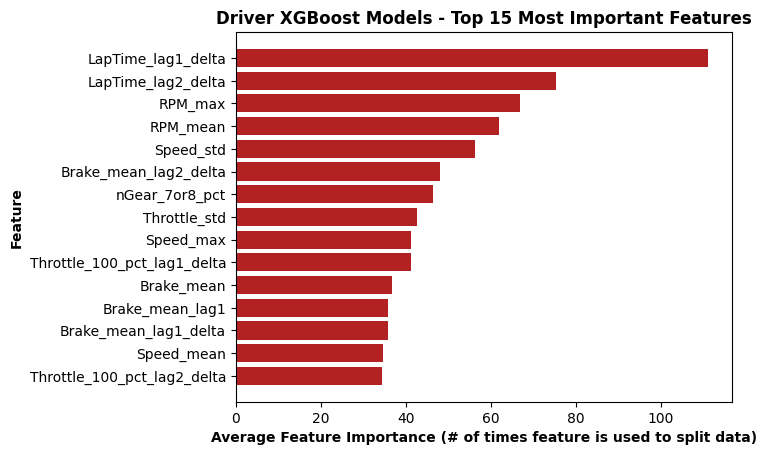

In [ ]:
def get_feature_importance(model):
  feature_importance = model.get_booster().get_score(importance_type='weight')
  return feature_importance

#get average importance of each feature
models = [VER_AbuDhabi, VER_Bahrain, VER_Mexico,
          GAS_AbuDhabi, GAS_Bahrain, GAS_Mexico,
          HAM_AbuDhabi, HAM_Bahrain, HAM_Mexico,
          NOR_AbuDhabi, NOR_Bahrain, NOR_Mexico,
          LEC_AbuDhabi, LEC_Bahrain, LEC_Mexico]
feature_importance_df = pd.DataFrame(columns=['Model', 'Feature', 'Importance'])
for model in models:
  feature_importance = get_feature_importance(model)
  for feature, importance in feature_importance.items():
    feature_importance_df.loc[len(feature_importance_df)] = [model, feature, importance]

feature_importance_df = feature_importance_df.groupby('Feature')['Importance'].mean().reset_index()
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df
feature_importance_df.to_csv('/content/drive/MyDrive/ML/feature_importance.csv', index=False)

#graph top 10 most important features
feature_importance_t10 = feature_importance_df.head(15).sort_values(by='Importance', ascending=True)
plt.barh(feature_importance_t10['Feature'], feature_importance_t10['Importance'], color='firebrick')
plt.xlabel('Average Feature Importance (# of times feature is used to split data)', fontweight='bold')
plt.ylabel('Feature', fontweight='bold')
plt.title('Driver XGBoost Models - Top 15 Most Important Features', fontweight='bold')
plt.show()

# Reload models if session ends

In [12]:
#reload xgboost models from .pkl files
import pickle
import os

model_path_prefix = '/content/drive/MyDrive/ML/MODELS/'

def load_model_safely(filepath):
    if not os.path.exists(filepath):
        raise FileNotFoundError(
            f"Model file not found: {filepath}. "
            "Please ensure Google Drive is mounted (cell bqVlA6UT9_sU) "
            "and the models have been successfully saved (cell wak6xB2_8x3I)."
        )
    return pickle.load(open(filepath, 'rb'))

try:
    VER_AbuDhabi = load_model_safely(model_path_prefix + 'VER_AbuDhabi.pkl')
    VER_Bahrain = load_model_safely(model_path_prefix + 'VER_Bahrain.pkl')
    VER_Mexico = load_model_safely(model_path_prefix + 'VER_Mexico.pkl')

    GAS_AbuDhabi = load_model_safely(model_path_prefix + 'GAS_AbuDhabi.pkl')
    GAS_Bahrain = load_model_safely(model_path_prefix + 'GAS_Bahrain.pkl')
    GAS_Mexico = load_model_safely(model_path_prefix + 'GAS_Mexico.pkl')

    HAM_AbuDhabi = load_model_safely(model_path_prefix + 'HAM_AbuDhabi.pkl')
    HAM_Bahrain = load_model_safely(model_path_prefix + 'HAM_Bahrain.pkl')
    HAM_Mexico = load_model_safely(model_path_prefix + 'HAM_Mexico.pkl')

    NOR_AbuDhabi = load_model_safely(model_path_prefix + 'NOR_AbuDhabi.pkl')
    NOR_Bahrain = load_model_safely(model_path_prefix + 'NOR_Bahrain.pkl')
    NOR_Mexico = load_model_safely(model_path_prefix + 'NOR_Mexico.pkl')

    LEC_AbuDhabi = load_model_safely(model_path_prefix + 'LEC_AbuDhabi.pkl')
    LEC_Bahrain = load_model_safely(model_path_prefix + 'LEC_Bahrain.pkl')
    LEC_Mexico = load_model_safely(model_path_prefix + 'LEC_Mexico.pkl')

except FileNotFoundError as e:
    print(e)

# Use models to predict clean lap times from year unseen by model (2024)
Predictions were just as effective, sometimes even more accurate compared to the random test set from 2019/21/23/25

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

features = ['RPM_mean', 'RPM_max', 'Speed_mean', 'Speed_max', 'Speed_min',
            'Speed_std', 'Throttle_mean', 'Throttle_std', 'nGear_7or8_pct',
            'Throttle_100_pct', 'Brake_mean', 'LapTime', 'LapTime_lag1',
            'LapTime_lag2', 'LapTime_lag1_delta', 'LapTime_lag2_delta',
            'Speed_max_lag1', 'Speed_max_lag2', 'Speed_max_lag1_delta',
            'Speed_max_lag2_delta', 'Throttle_100_pct_lag1', 'Throttle_100_pct_lag2',
            'Throttle_100_pct_lag1_delta', 'Throttle_100_pct_lag2_delta',
            'Brake_mean_lag1', 'Brake_mean_lag2', 'Brake_mean_lag1_delta',
            'Brake_mean_lag2_delta']


def predict_2024(model_obj, driver, race, features_list, yr=2024):
    #get 2024 telemetry data for the specified driver and race
    tel_2024 = get_driver_telemetry(yr, race, driver)
    tel_2024 = preprocess(tel_2024)
    tel_2024 = get_pace_deg_delta(tel_2024)
    relevant_cols_for_pred = features_list + ['LapTime_next', 'DeltaPred_PaceDegModel', 'LapTime']
    tel_2024 = tel_2024.dropna(subset=relevant_cols_for_pred).copy()

    #select only the features columns for prediction
    X_predict_2024 = tel_2024[features_list]
    y_true_2024 = tel_2024['LapTime_next']

    #add driver and race column
    tel_2024['Driver'] = driver
    tel_2024['Race'] = race

    #make predictions on the full feature set at once
    tel_2024['PRED_DeltaNextLap'] = model_obj.predict(X_predict_2024)
    tel_2024['PRED_NextLap'] = tel_2024['LapTime'] + tel_2024['PRED_DeltaNextLap']
    tel_2024['PRED_Error'] = tel_2024['PRED_NextLap'] - tel_2024['LapTime_next']

    #compare with predictions just from pace deg model
    tel_2024['NextLapPred_PaceDegModel'] = tel_2024['LapTime'] + tel_2024['DeltaPred_PaceDegModel']
    tel_2024['Error_PaceDegModel'] = tel_2024['NextLapPred_PaceDegModel'] - tel_2024['LapTime_next']

    #calculate and print metrics
    rmse_driver_model = np.sqrt(mean_squared_error(y_true_2024, tel_2024['PRED_NextLap']))
    mae_driver_model = mean_absolute_error(y_true_2024, tel_2024['PRED_NextLap'])
    rmse_pace_deg = np.sqrt(mean_squared_error(y_true_2024, tel_2024['NextLapPred_PaceDegModel']))
    mae_pace_deg = mean_absolute_error(y_true_2024, tel_2024['NextLapPred_PaceDegModel'])

    print(f"RMSE (Driver Model for {driver} {race}): {rmse_driver_model}")
    print(f"MAE (Driver Model for {driver} {race}): {mae_driver_model}")
    print(f"RMSE (Pace Deg Model for {driver} {race}): {rmse_pace_deg}")
    print(f"MAE (Pace Deg Model for {driver} {race}): {mae_pace_deg}")

    return tel_2024[['Driver', 'Race', 'LapNumber', 'LapTime', 'LapTime_next', 'PRED_NextLap', 'PRED_Error', 'NextLapPred_PaceDegModel', 'Error_PaceDegModel']]

#try it out
VER_AD_24 = predict_2024(VER_AbuDhabi, 'VER', 'Abu Dhabi', features)
VER_BA_24 = predict_2024(VER_Bahrain, 'VER', 'Bahrain', features)
VER_MX_22 = predict_2024(VER_Mexico, 'VER', 'Mexico City', features)
GAS_AD_24 = predict_2024(GAS_AbuDhabi, 'GAS', 'Abu Dhabi', features)
GAS_BA_24 = predict_2024(GAS_Bahrain, 'GAS', 'Bahrain', features)
GAS_MX_24 = predict_2024(GAS_Mexico, 'GAS', 'Mexico City', features)
HAM_AD_24 = predict_2024(HAM_AbuDhabi, 'HAM', 'Abu Dhabi', features)
HAM_BA_24 = predict_2024(HAM_Bahrain, 'HAM', 'Bahrain', features)
HAM_MX_24 = predict_2024(HAM_Mexico, 'HAM', 'Mexico City', features)
NOR_AD_24 = predict_2024(NOR_AbuDhabi, 'NOR', 'Abu Dhabi', features)
NOR_BA_24 = predict_2024(NOR_Bahrain, 'NOR', 'Bahrain', features)
NOR_MX_24 = predict_2024(NOR_Mexico, 'NOR', 'Mexico City', features)
LEC_AD_24 = predict_2024(LEC_AbuDhabi, 'LEC', 'Abu Dhabi', features)
LEC_BA_24 = predict_2024(LEC_Bahrain, 'LEC', 'Bahrain', features)
LEC_MX_24 = predict_2024(LEC_Mexico, 'LEC', 'Mexico City', features)

ALL_PREDS_24 = pd.concat([VER_AD_24, VER_BA_24, VER_MX_22, GAS_AD_24, GAS_BA_24,
                          GAS_MX_24, HAM_AD_24, HAM_BA_24, HAM_MX_24, NOR_AD_24,
                          NOR_BA_24, NOR_MX_24, LEC_AD_24, LEC_BA_24, LEC_MX_24])

# Compare Pace Deg and XGBoost model performance on 2024 clean laps
Performance was very similar. XGB and PaceDeg usually have almost the same MAE, although one marginally outperforms the other on occasion.

In [23]:
#group all preds by driver and race and get mean absolute error for pace deg and xgboost model
ALL_PREDS_24['XGB_AbsError'] = abs(ALL_PREDS_24['PRED_Error'])
ALL_PREDS_24['PaceDeg_AbsError'] = abs(ALL_PREDS_24['Error_PaceDegModel'])
MAEs_24 = ALL_PREDS_24.groupby(['Driver', 'Race'])[['XGB_AbsError', 'PaceDeg_AbsError']].mean()
MAEs_24

XGB_AbsError  PaceDeg_AbsError
Driver Race                                       
GAS    Abu Dhabi        0.252289          0.277183
       Bahrain          0.355986          0.351558
       Mexico City      0.388863          0.440150
HAM    Abu Dhabi        0.298087          0.287406
       Bahrain          0.308073          0.309483
       Mexico City      0.387032          0.404559
LEC    Abu Dhabi        0.219818          0.220812
       Bahrain          0.229178          0.217670
       Mexico City      0.334835          0.334499
NOR    Abu Dhabi        0.230526          0.200221
       Bahrain          0.179034          0.143875
       Mexico City      0.376456          0.288780
VER    Abu Dhabi        0.277640          0.265879
       Bahrain          0.268513          0.270896
       Mexico City      0.220769          0.247850

### Investigate the race most heavily favored by XGBoost (Norris Mexico) and the race most heavily favored by PaceDeg (Gasly Mexico)
Key observation: more variance in the Norris Mexico race. Perhaps the XGBoost driver model is more adaptable to variance/noise in clean laps, but when the race is very clean and not very noisy, the complexity overfits ever-so-slightly, giving Pace Deg the edge.

In [46]:
#PaceDeg Outperformed XGBoost by .06 here, lets check it out
NOR_MEX_Laps_2024 = get_driver_telemetry(2024, 'Mexico City', 'NOR')
NOR_MEX_Laps_2024 = preprocess(NOR_MEX_Laps_2024)
#XGBoost outperformed PaceDeg by .09 here, check it out
GAS_MEX_Laps_2024 = get_driver_telemetry(2024, 'Mexico City', 'GAS')
GAS_MEX_Laps_2024 = preprocess(GAS_MEX_Laps_2024)

print("LANDO NORRIS MEXICO 2024 - XGB OUTPERFORMED BY .06")
print(NOR_MEX_Laps_2024.describe())
print('\n\n\n\n\n')
print("LANDO NORRIS MEXICO 2024 - PACE DEG OUTPERFORMED BY .09")
print(GAS_MEX_Laps_2024.describe())

LANDO NORRIS MEXICO 2024 - XGB OUTPERFORMED BY .06
         Year  LapNumber     RPM_mean       RPM_max  Speed_mean   Speed_max  \
count    60.0  60.000000    60.000000     60.000000   60.000000   60.000000   
mean   2024.0  39.033333  9815.965874  12304.033333  187.939823  332.333333   
std       0.0  19.116917    72.489581    171.734913    2.708690    9.112604   
min    2024.0   7.000000  9426.318471  11926.000000  180.945860  323.000000   
25%    2024.0  21.750000  9778.645066  12164.750000  185.525451  327.000000   
50%    2024.0  40.500000  9833.272277  12321.500000  188.654424  329.000000   
75%    2024.0  55.250000  9857.598588  12445.000000  189.759205  332.000000   
max    2024.0  70.000000  9941.158576  12585.000000  193.024055  354.000000   

       Speed_min  Speed_std  Throttle_mean  Throttle_std  ...  \
count  60.000000  60.000000      60.000000     60.000000  ...   
mean   63.983333  81.024152      55.093193     43.185902  ...   
std     2.029375   1.996801       1.404549

#Visualize Pace Deg vs XGBoost performance on 2024 clean laps

/tmp/ipykernel_3315/1317570075.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([MAEs_24['PaceDeg_AbsError'], MAEs_24['XGB_AbsError']], labels=['Pace Deg', 'XGBoost'], showfliers=False, vert=False, widths=0.8, patch_artist=True)


Text(0.5, 1.0, 'Comparison of Pace Deg and XGBoost Performance')

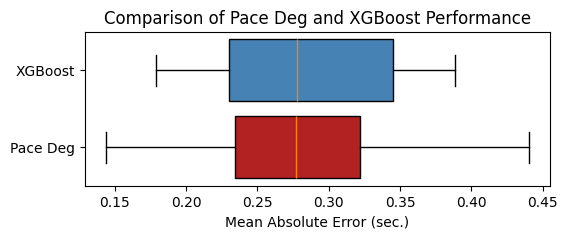

In [24]:
#compare PaceDeg and XGBoost Performance
plt.style.use('default')
plt.figure(figsize=(6, 2))
bp = plt.boxplot([MAEs_24['PaceDeg_AbsError'], MAEs_24['XGB_AbsError']], labels=['Pace Deg', 'XGBoost'], showfliers=False, vert=False, widths=0.8, patch_artist=True)

# Set colors for the boxes
colors = ['firebrick', 'steelblue', 'slategray']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.xlabel('Mean Absolute Error (sec.)')
plt.title('Comparison of Pace Deg and XGBoost Performance')

# Ensembling Attempt #1: add PaceDeg predictions as feature
Test 3 variations in comparison to original model

Result: model had minimal impact on MAE, always less than 0.01, sometimes increased MAE

core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Abu Dhabi Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core     

Fitting 4 folds for each of 25 candidates, totalling 100 fits


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...


Best Params:
 {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.8}
Test MAE: 0.22893177108848634
Test RMSE: 0.4113836354070416


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F

Fitting 4 folds for each of 25 candidates, totalling 100 fits


core           INFO 	Loading data for Mexican Grand Prix - Race [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Mexican Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...


Best Params:
 {'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.6}
Test MAE: 0.4116310103050227
Test RMSE: 0.6638774523952965


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F

Fitting 4 folds for each of 25 candidates, totalling 100 fits
Best Params:
 {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.6}
Test MAE: 0.2200679272602232
Test RMSE: 0.2685430816889989


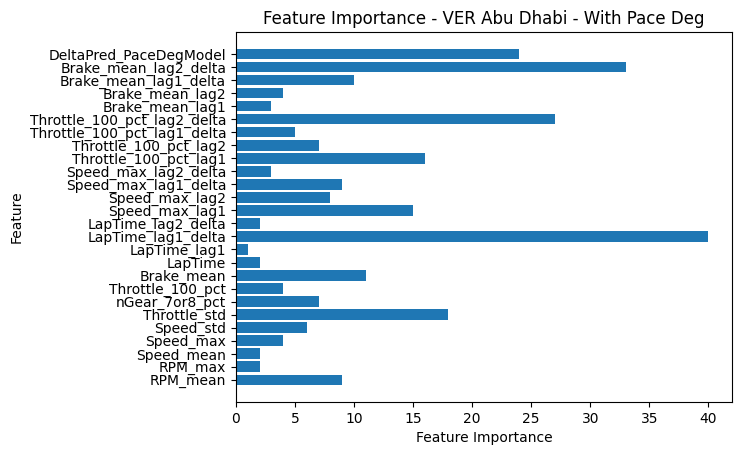

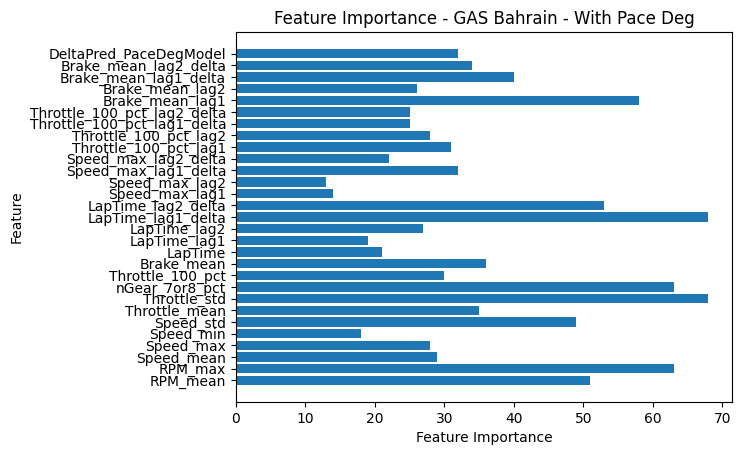

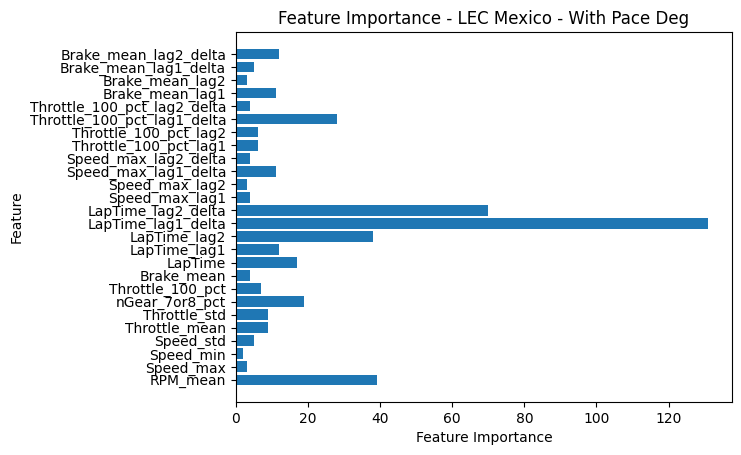

In [35]:
#New version

features = ['RPM_mean', 'RPM_max', 'Speed_mean', 'Speed_max', 'Speed_min',
            'Speed_std', 'Throttle_mean', 'Throttle_std', 'nGear_7or8_pct',
            'Throttle_100_pct', 'Brake_mean', 'LapTime', 'LapTime_lag1',
            'LapTime_lag2', 'LapTime_lag1_delta', 'LapTime_lag2_delta',
            'Speed_max_lag1', 'Speed_max_lag2', 'Speed_max_lag1_delta',
            'Speed_max_lag2_delta', 'Throttle_100_pct_lag1', 'Throttle_100_pct_lag2',
            'Throttle_100_pct_lag1_delta', 'Throttle_100_pct_lag2_delta',
            'Brake_mean_lag1', 'Brake_mean_lag2', 'Brake_mean_lag1_delta',
            'Brake_mean_lag2_delta', 'DeltaPred_PaceDegModel'] #<--- PACEDEG PREDICTIONS

VER_AbuDhabi_wPaceDegPreds = full_model('VER', 'Abu Dhabi')
GAS_Bahrain_wPaceDegPreds = full_model('GAS', 'Bahrain')
LEC_Mexico_wPaceDegPreds = full_model('LEC', 'Mexico')

#print feature importance chart
import matplotlib.pyplot as plt
feature_importance = VER_AbuDhabi_wPaceDegPreds.get_booster().get_score(importance_type='weight')
plt.barh(list(feature_importance.keys()), feature_importance.values())
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - VER Abu Dhabi - With Pace Deg')
plt.show()

#print feature importance chart
import matplotlib.pyplot as plt
feature_importance = GAS_Bahrain_wPaceDegPreds.get_booster().get_score(importance_type='weight')
plt.barh(list(feature_importance.keys()), feature_importance.values())
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - GAS Bahrain - With Pace Deg')
plt.show()

#print feature importance chart
import matplotlib.pyplot as plt
feature_importance = LEC_Mexico_wPaceDegPreds.get_booster().get_score(importance_type='weight')
plt.barh(list(feature_importance.keys()), feature_importance.values())
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - LEC Mexico - With Pace Deg')
plt.show()

In [36]:
#get last 3 rows of model_info
model_info.tail(3)

#VER Abu Dhabi MAE pre-PaceDeg: 0.228133
#GAS Bahrain MAE pre-PaceDeg: 0.419035
#LEC Mexico MAE pre-PaceDeg: 	0.219719
#Little to no impact, sometimes impact is even slightly negative on performance

,Driver,Race,RMSE,MAE
1,VER,Abu Dhabi,0.411384,0.228932
2,GAS,Bahrain,0.663877,0.411631
3,LEC,Mexico,0.268543,0.220068


# Ensemble Attempt #2: Linearly fit both predictions to get optimal weights
Quite literally just gives all weight to the XGBoost prediction and then some.

In [25]:
from sklearn.linear_model import LinearRegression

X = ALL_PREDS_24[['PRED_NextLap', 'NextLapPred_PaceDegModel']]
y = ALL_PREDS_24['LapTime_next']

meta_model = LinearRegression(fit_intercept=False)
meta_model.fit(X, y)

print(meta_model.coef_)  #weights

[ 1.0437768  -0.04431964]


# Conclusion

Both the Pace Deg linear regression model and the XGBoost telemetry model perform similarly well. However, ensembling them does not improve performance, suggesting that both models, although being trained on completely different data, capture the same signals.